# ***01_FFT***

(0.0, 10.0)

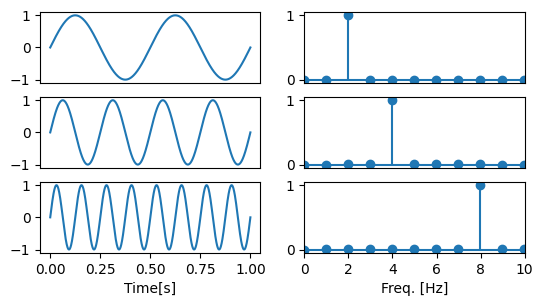

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import fft

t = np.linspace(0, 1, 1024)
f = fft.rfftfreq(len(t), t[1]-t[0])
N = len(t)

## 2 Cycles / Second
x1 = np.sin(2*2*np.pi*t)
f1 = fft.rfft(x1) / (N/2)

plt.figure(figsize=(16/2.56, 8/2.56))
plt.subplot(3,2,1)
plt.plot(t, x1)
plt.xticks([])

plt.subplot(3,2,2)
plt.stem(f, np.abs(f1), basefmt="")
plt.xticks([])
plt.xlim(0,10)


# 4 Cycles / Second
x2 = np.sin(4*2*np.pi*t)
f2 = fft.rfft(x2) / (N/2)

plt.subplot(3,2,3)
plt.plot(t, x2)
plt.xticks([])

plt.subplot(3,2,4)
plt.stem(f, np.abs(f2), basefmt="")
plt.xticks([])
plt.xlim(0,10)



## 8 Cycles / Second
x3 = np.sin(8*2*np.pi*t)
f3 = fft.rfft(x3) / (N/2)

plt.subplot(3,2,5)
plt.plot(t, x3)
plt.xlabel('Time[s]')

plt.subplot(3,2,6)
plt.stem(f, np.abs(f3), basefmt="")
plt.xlabel('Freq. [Hz]')
plt.xlim(0,10)

***Spectral Leakage***

(0.0, 1.0)

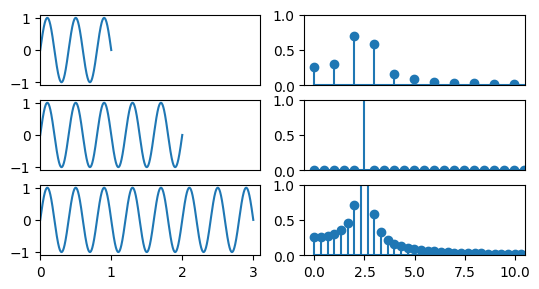

In [ ]:
## 2.5 Cycles / Second
plt.figure(figsize=(16/2.56, 8/2.56))
t = np.linspace(0, 1, 1024)
N = len(t)
f = fft.rfftfreq(len(t), t[1]-t[0])

x1 = np.sin(2.5*2*np.pi*t)
f1 = fft.rfft(x1) / (N/2)

plt.subplot(3,2,1)
plt.plot(t, x1)
plt.xlim(0, 3.1)
plt.xticks([])

plt.subplot(3,2,2)
plt.stem(f, np.abs(f1), basefmt="")
plt.xlim(-0.5,10.5)
plt.ylim(0,1)
plt.xticks([])

t = np.linspace(0, 2, 1024*2)
f = fft.rfftfreq(len(t), t[1]-t[0])

x1 = np.sin(2.5*2*np.pi*t)
f1 = fft.rfft(x1) / (N/2)
plt.subplot(3,2,3)
plt.plot(t, x1)
plt.xlim(0, 3.1)
plt.xticks([])

plt.subplot(3,2,4)
plt.stem(f, np.abs(f1), basefmt="")
plt.xlim(-0.5, 10.5)
plt.ylim(0,1)
plt.xticks([])


t = np.linspace(0, 3, 1024*3)
f = fft.rfftfreq(len(t), t[1]-t[0])

x1 = np.sin(2.5*2*np.pi*t)
f1 = fft.rfft(x1) / (N/2)
plt.subplot(3,2,5)
plt.plot(t, x1)
plt.xlim(0, 3.1)

plt.subplot(3,2,6)
plt.stem(f, np.abs(f1), basefmt="")
plt.xlim(-0.5, 10.5)
plt.ylim(0,1)




***Spectral Aliasing***

(0.0, 1.0)

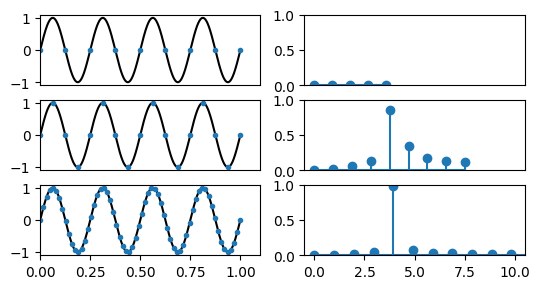

In [ ]:
## 1 Cycle / Second
t0 = np.linspace(0, 1, 1024)
x0 = np.sin(4*2*np.pi*t0)
N = len(t0)

t1 = np.linspace(0, 1, 9)
x1 = np.sin(4*2*np.pi*t1)
N = len(t1)
freq = fft.rfftfreq(len(t1), t1[1]-t1[0])
f1 = fft.rfft(x1) / (N/2)

plt.figure(figsize=(16/2.56, 8/2.56))
plt.subplot(3,2,1)
plt.plot(t0, x0, 'k')
plt.plot(t1, x1, '.')
plt.xlim(0, 1.1)
plt.xticks([])

plt.subplot(3,2,2)
plt.stem(freq, np.abs(f1), basefmt="")
plt.xlim(-0.5,10.5)
plt.ylim(0,1)
plt.xticks([])


t2 = np.linspace(0, 1, 17)
x2 = np.sin(4*2*np.pi*t2)
N = len(t2)
freq = fft.rfftfreq(len(t2), t2[1]-t2[0])
f2 = fft.rfft(x2) / (N/2)

plt.subplot(3,2,3)
plt.plot(t0, x0,'k')
plt.plot(t2, x2, '.')
plt.xlim(0, 1.1)
plt.xticks([])

plt.subplot(3,2,4)
plt.stem(freq, np.abs(f2), basefmt="")
plt.xlim(-0.5,10.5)
plt.ylim(0,1)
plt.xticks([])


t3 = np.linspace(0, 1, 64)
x3 = np.sin(4*2*np.pi*t3)
N = len(t3)
freq = fft.rfftfreq(len(t3), t3[1]-t3[0])
f3 = fft.rfft(x3) / (N/2)

plt.subplot(3,2,5)
plt.plot(t0, x0,'k')
plt.plot(t3, x3, '.')
plt.xlim(0, 1.1)


plt.subplot(3,2,6)
plt.stem(freq, np.abs(f3), basefmt="")
plt.xlim(-0.5,10.5)
plt.ylim(0,1)



***Compare fft and rfft***

In [ ]:
t = np.linspace(0, 1, 1024)
f = fft.rfftfreq(len(t), t[1]-t[0])
N = len(t)

x1 = np.sin(2*2*np.pi*t)
f1 = fft.rfft(x1) / (N/2)
f2 = fft.fft(x1) / (N/2)

print(len(f1), len(f2))

513 1024






---
***02_Filtering***

***Generate Sample Data***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft, signal

fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
N = len(t)
x = np.sin(1*2*np.pi*t) + np.sin(10*2*np.pi*t) + np.sin(100*2*np.pi*t)
freq = fft.rfftfreq(len(t), t[1]-t[0])
X_f = fft.rfft(x) / (N/2)

plt.figure(figsize=(10/2.56, 7.8/2.56))
plt.subplot(2,1,1)
plt.plot(t, x, linewidth=0.5)
plt.xlim(0,1)
plt.xlabel("Time")M
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.stem(freq, np.abs(X_f), basefmt="")
plt.xlim(0,200)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.subplots_adjust(hspace=0.6)
plt.show()


***Filtering***

In [ ]:
# Design Filter (Butterworth Low-Pass)
cutoff_freq = 50  # Cutoff at 50Hz
order = 4
b, a = signal.butter(order, cutoff_freq, btype='low', fs=fs)
w, h = signal.freqz(b, a, worN=len(x), fs=fs) # For Visualization

# Apply Filter
x_filt = signal.filtfilt(b, a, x)
X_f_filt = fft.rfft(x_filt) / (N/2)

plt.figure(figsize=(10/2.56, 3/2.56))
plt.plot(w, np.abs(h), color='darkorange', linewidth=2, linestyle='-', label='Filter Response')
plt.fill_between(w, 0, np.abs(h), color='orange', alpha=0.1) # Fill under the curve

# Annotations
plt.axvline(x=cutoff_freq, color='black', linestyle=':', alpha=0.5)
plt.text(cutoff_freq + 10, 0.8, f'Cutoff {cutoff_freq}Hz', color='black')
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.xlim(0,200)

plt.subplots_adjust(hspace=0.9)
plt.show()


plt.figure(figsize=(10/2.56, 3/2.56))
plt.stem(freq, np.abs(X_f_filt), basefmt="")
plt.xlim(0,200)
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.ylim(-0.1, 1.1)


***Manual Filtering***

In [ ]:
# Impulse response of the filter: H(f)
impulse = np.zeros_like(x)
impulse[0] = 1
h_impulse = signal.lfilter(b, a, impulse) # 1차 필터 응답
H_f = fft.rfft(h_impulse)
H_f_squared = np.abs(H_f)**2
X_f_manual = X_f * H_f_squared

plt.figure(figsize=(10/2.56, 3/2.56))
plt.stem(freq, np.abs(X_f_filt), basefmt="")
plt.title('Filtered FFT by filtfilt')
plt.figure(figsize=(10/2.56, 3/2.56))
plt.stem(freq, np.abs(X_f_manual), basefmt="")
plt.title('Manually Filtered FFT')
plt.show()

***Order***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal,fft

fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
N = len(t)
x = np.sin(1*2*np.pi*t) + np.sin(10*2*np.pi*t) + np.sin(100*2*np.pi*t)
x[500:5005] += 3              # impulse (결함 유사 신호)
freq = fft.rfftfreq(len(t), t[1]-t[0])
X_f = fft.rfft(x) / (N/2)

cutoff = 50
order = 4

# Butterworth LPF
b_butt, a_butt = signal.butter(order, cutoff / (fs / 2), btype='low')

# Elliptic LPF (급격한 필터)
b_ellip, a_ellip = signal.ellip(order, 0.5, 40, cutoff / (fs / 2), btype='low')

# Zero-phase filtering
y_butt = signal.filtfilt(b_butt, a_butt, x)
y_ellip = signal.filtfilt(b_ellip, a_ellip, x)

# -----------------------------
# 3. 시간 영역 비교
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Original Signal', alpha=0.5)
plt.plot(t, y_butt, label='Butterworth Filtered')
plt.plot(t, y_ellip, label='Elliptic Filtered', linestyle='--')
plt.xlim(0.48, 0.58)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Time Domain Comparison (Impulse Region)')
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 4. 주파수 응답 비교
# -----------------------------
w, h_butt = signal.freqz(b_butt, a_butt, fs=fs)
w, h_ellip = signal.freqz(b_ellip, a_ellip, fs=fs)

plt.figure(figsize=(10, 5))
plt.plot(w, 20 * np.log10(np.abs(h_butt)), label='Butterworth')
plt.plot(w, 20 * np.log10(np.abs(h_ellip)), label='Elliptic', linestyle='--')
plt.axvline(cutoff, color='k', linestyle=':', label='Cutoff')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('Frequency Response Comparison')
plt.legend()
plt.grid()
plt.show()




---



---
03_Envelope


***Generate Sample Data***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.fft import rfft, rfftfreq

fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)

# 1) cosine 신호
signal = np.cos(2 * np.pi * 50 * t)            # 회전속도 50 Hz

# 2) 진폭 변조 cosine 신호
#carrier = np.cos(2 * np.pi * 50 * t)            # 회전속도 50 Hz
#modulator = 1 + 0.5 * np.cos(2 * np.pi * 5 * t) # 베어링 결함주파수: 5Hz (진폭 변화)
#signal = modulator * carrier                    # 진폭 변조된 신호

# Apply Hilbert Transform
analytic_signal = hilbert(signal) # returns the Analytic Signal: z(t) = x(t) + j*H(x(t))

# Extract the Hilbert Transform component (The Imaginary Part)
hilbert_transform = np.imag(analytic_signal)
envelope = np.abs(analytic_signal)

# Visualization
plt.figure(figsize=(13.8/2.56, 7.2/2.56))
plt.plot(t, signal, label=r'Original Signal', color='blue', linewidth=2)
plt.plot(t, hilbert_transform, label=r'Hilbert Transform (Shifted -90°)',
         color='red', linestyle='--', linewidth=2)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', bbox_to_anchor=(1.0,1.0), fontsize=11)

peak_idx = np.argmax(signal)
plt.plot(t[peak_idx], signal[peak_idx], 'bo')
plt.plot(t[peak_idx], hilbert_transform[peak_idx], 'ro')

plt.xlim(0, 0.1)
plt.show()

***Visualize Analytic Signal***

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

analytic_signal = hilbert(signal)
amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.angle(analytic_signal) # 위상 정보

real_part = np.real(analytic_signal)[:100]      # 원래 신호와 동일
imag_part = np.imag(analytic_signal)[:100]      # 90도 위상 지연된 신호 (힐버트 변환값)
t = t[:100]

fig = plt.figure(figsize=(12/2.56, 10/2.56))
ax = fig.add_subplot(111, projection='3d')

# A. 실수부(Cosine) 그리기 -> X-Z 평면 (Y=0 인 평면)
# (x=값, y=0, z=시간)
ax.plot(real_part, np.zeros_like(t), t, label='Real Part (Cosine) on X-Z Plane', color='blue', linewidth=2)

# B. 허수부(Sine) 그리기 -> Y-Z 평면 (X=0 인 평면)
# (x=0, y=값, z=시간)
ax.plot(np.zeros_like(t), imag_part, t, label='Imaginary Part (Sine) on Y-Z Plane', color='red', linewidth=2)

ax.set_xlabel('Real Axis (X)', fontsize=12,  color='blue')
ax.set_ylabel('Imaginary Axis (Y)', fontsize=12, color='red')
ax.set_zlabel('Time Axis (Z)', fontsize=12)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(0, 0.1)
ax.set_xticks([-1.0, 0, 1.0])
ax.set_yticks([-1.0, 0, 1.0])
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()


***Example 2) Bearing Fault Analysis***


In [ ]:
fs = 10000       # 샘플링 10kHz
T = 1.0
t = np.linspace(0, T, int(fs*T), endpoint=False)
N = len(t)

# 베어링 결함 주파수(BPFO)가 50Hz라고 가정
# 베어링 고유 주파수 3000Hz 가정
carrier_freq = 3000
fault_freq = 50

# 충격 신호 생성: 50Hz 주기로 '1'이 되는 임펄스열 생성 후 exponential decay 적용
impacts = np.zeros_like(t)
impact_indices = np.arange(0, len(t), int(fs/fault_freq))
impacts[impact_indices] = 1.0

response = np.exp(-1000 * (t % (1/fault_freq))) # 감쇠 envelope
vibration_signal = response * np.sin(2 * np.pi * carrier_freq * t)
vibration_signal += 0.1 * np.random.randn(len(t))  # 노이즈 추가


analytic_signal = hilbert(vibration_signal)
envelope = np.abs(analytic_signal)
yf_raw = np.abs(rfft(vibration_signal)) /  (N/2)
xf_raw = rfftfreq(len(t), 1/fs)
yf_env = np.abs(rfft(envelope - np.mean(envelope))) / (N/2)
xf_env = rfftfreq(len(t), 1/fs)


# 시각화
plt.figure(figsize=(13.8/2.56, 15/2.56))

plt.subplot(3, 1, 1)
plt.plot(t[:1000], vibration_signal[:1000], label='Raw Signal (Resonance)', color='lightgray')
plt.plot(t[:1000], envelope[:1000], label='Extracted Envelope', color='red', linewidth=2)
plt.xlabel("Time (s)")

# [주파수 영역 - 일반 FFT]
plt.subplot(3, 1, 2)
plt.plot(xf_raw, yf_raw, color='gray')
plt.xlim(0, 5000)
plt.annotate('Resonance (3000Hz)\nMasks the fault!', xy=(3000, np.max(yf_raw)),
             xytext=(3500, np.max(yf_raw)), arrowprops=dict(facecolor='black'))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")


# [주파수 영역 - Envelope FFT]
plt.subplot(3, 1, 3)
plt.plot(xf_env, yf_env, color='red')
plt.xlim(0, 200) # 저주파 확대
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.annotate(f'Fault Frequency ({fault_freq}Hz)\nDETECTED!', xy=(fault_freq, np.max(yf_env)),
             xytext=(fault_freq+20, np.max(yf_env)), arrowprops=dict(facecolor='black'))

plt.tight_layout()
plt.show()